In [ ]:
!pip install statannot
!pip install scikit-optimize
!pip install shap
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split


import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split

from __future__ import division
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBClassifier
#import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
from xgboost import plot_importance
import plotly.graph_objects as go
from tqdm.notebook import tqdm
from sklearn.model_selection import RepeatedKFold
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, accuracy_score, recall_score, precision_score, confusion_matrix, mean_squared_error
import seaborn as sns
from statannot import add_stat_annotation
from sklearn.linear_model import Lasso, MultiTaskLasso, Ridge, ElasticNet

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import mutual_info_regression, f_regression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.decomposition import PCA

from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

from sklearn import metrics


from skopt import BayesSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet

import statsmodels.api as sm

import time

import scipy

from sklearn.svm import SVR

from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestRegressor

from statsmodels.stats.multitest import fdrcorrection

from statsmodels.stats import multitest

from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.ensemble import ExtraTreesClassifier

from collections import Counter
import heapq

import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor

import re

from sklearn.preprocessing import MinMaxScaler

import os

import pandas as pd
from sklearn.utils import resample
from sklearn.cluster import KMeans


In [ ]:
def determinar_intervalo(min_val, max_val, x):


    pasos = np.linspace(min_val, max_val, 7)

    if(max_val == x):
        return 6


    for i in range(7):
        if pasos[i] <= x < pasos[i+1]:
            return (i)
    return None

def rgba_to_hex(rgba):
    """
    Convierte un color en formato RGBA a formato hexadecimal.

    Parámetros:
    - rgba: Tupla con los valores (R, G, B, A) en rango 0-255.

    Devuelve:
    - Color en formato hexadecimal.
    """
    return "#{:02X}{:02X}{:02X}".format(rgba[0], rgba[1], rgba[2])


color_rgba = (255, 0, 0, 128)
color_hex = rgba_to_hex(color_rgba)
print(color_hex)


educ_palete = ['#cdffff', '#abe5eb',  '#8acbd8', '#6bb1c6', '#4c98b5', '#2d7fa3', '#006691']
sex_palete = ['#fffff1', '#fcfade',  '#faf5cb', '#f8f0b8', '#f7eaa5', '#f7e492', '#f8de7e']
age_palete = ['#98ffe0', '#80e4c4',  '#69caa8', '#52b18d', '#3b9873', '#23805a', '#026842']
MMSE_palete = ['#ff9ea2', '#f0888b',  '#e07275', '#d05b5f', '#bf4549', '#ae2c34', '#9c0720']
GINI_palete = ['#ffd5bd', '#ffbe99',  '#ffa777', '#fd8f56', '#f87734', '#ff5e00', '#f25c05']

#FF0000


In [ ]:
from scipy.stats import linregress, combine_pvalues
from sklearn.model_selection import train_test_split, RepeatedKFold
import xgboost as xgb
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from tqdm import tqdm


def classifier_ROC(X_, y, diagnosis, fig_show=True, params_=None):


    X_train, X_test, y_train, y_test = train_test_split(X_, y, test_size=0.2, random_state=6000, stratify=diagnosis)
    print(X_train,y_train)

    n_splits=7 #10
    n_repeats=10#2

    cv = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=101)
    folds = [(train, test) for train, test in cv.split(X_train, y_train)]
    metrics = ['auc', 'fpr', 'tpr', 'thresholds', 'f1_score', 'accuracy_score', 'recall_score', 'precision_score', 'confusion_matrix', 'model']
    results = {
        'train': {m: [] for m in metrics},
        'val': {m: [] for m in metrics},
        'test': {m: [] for m in metrics}
    }
    X_train = pd.DataFrame(X_train)
    y_train = pd.DataFrame(y_train)

    if params_ is not None:
        params = params_
    else:
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            #'max_depth': 5,  # Ajusta la profundidad máxima
            #'learning_rate': 0.1,  # Disminuye la tasa de aprendizaje
            #'subsample': 0.8,  # Usa un 80% de los datos para cada iteración
            #'lambda': 1,  # Regularización L2
            #'alpha': 0,  # Regularización L1
            #'tree_method': 'hist',  # Usar GPU
            #'device': 'cuda'  # Usar GPU
            }

    plt.rcParams["figure.figsize"] = (10, 10)
    dtest = xgb.DMatrix(X_test, label=y_test)

    all_p_values = {feature: [] for feature in X_train.columns}
    slopes = {feature: [] for feature in X_train.columns}
    correlations = {feature: [] for feature in X_train.columns}
    intercepts = {feature: [] for feature in X_train.columns}
    directions = {feature: [] for feature in X_train.columns}
    r_squared = {feature: [] for feature in X_train.columns}
    t_values = {feature: [] for feature in X_train.columns}
    f_values = {feature: [] for feature in X_train.columns}
    f_p_values = {feature: [] for feature in X_train.columns}
    r_values = {feature: [] for feature in X_train.columns}
    cohen_f2_values = {feature: [] for feature in X_train.columns}


    #slopes = []
    #intercepts = []
    #directions = []


    p_values_per_iteration = {feature: [] for feature in X_train.columns}

    for train_idx, test_idx in tqdm(folds, total=len(folds)):
        dtrain = xgb.DMatrix(X_train.iloc[train_idx, :], label=y_train.iloc[train_idx])
        dval = xgb.DMatrix(X_train.iloc[test_idx, :], label=y_train.iloc[test_idx])
        model = xgb.train(
            dtrain=dtrain,
            params=params,
            evals=[(dtrain, 'train'), (dval, 'val')],
            num_boost_round=1000,
            verbose_eval=False,
            early_stopping_rounds=10,
        )
        last_model = model
        sets = [dtrain, dval, dtest]

        for i, ds in enumerate(results.keys()):
            y_preds = model.predict(sets[i])
            labels = sets[i].get_label()
            fpr, tpr, thresholds = roc_curve(labels, y_preds)
            results[ds]['fpr'].append(fpr)
            results[ds]['tpr'].append(tpr)
            results[ds]['thresholds'].append(thresholds)
            results[ds]['auc'].append(roc_auc_score(labels, y_preds))

            results[ds]['f1_score'].append(f1_score(labels, np.round(y_preds)))
            results[ds]['accuracy_score'].append(accuracy_score(labels, np.round(y_preds)))
            results[ds]['recall_score'].append(recall_score(labels, np.round(y_preds)))
            results[ds]['precision_score'].append(precision_score(labels, np.round(y_preds)))
            results[ds]['confusion_matrix'].append(confusion_matrix(labels, np.round(y_preds)))
            results[ds]['model'].append(model)


        for feature in X_train.columns:
            X_feature = X_train[feature].iloc[train_idx].values
            y_train_squeezed = y_train.iloc[train_idx].squeeze().values

            if len(X_feature) == len(y_train_squeezed):
                slope, intercept, r_value, p_value, std_err = linregress(X_feature, y_train_squeezed)
                all_p_values[feature].append(p_value)



                slopes[feature].append(slope)
                correlations[feature].append(r_value)
                intercepts[feature].append(intercept)

                directions[feature].append(1 if slope > 0 else -1)


                aux=r_value**2
                r_squared[feature].append(aux)

                r_values[feature].append(r_value)


                cohen_f2 = (aux / (1 - aux))
                cohen_f2_values[feature].append(cohen_f2)


                X_feature_with_const = sm.add_constant(X_feature)
                model = sm.OLS(y_train_squeezed, X_feature_with_const).fit()


                t_values[feature].append(model.tvalues[1])
                f_values[feature].append(model.fvalue)
                f_p_values[feature].append(model.f_pvalue)

            else:
                print(f" {feature}: {len(X_feature)} vs {len(y_train_squeezed)}")


    combined_p = {feature: combine_pvalues(all_p_values[feature], method='fisher')[1] for feature in X_train.columns}



    average_slopes = {feature: np.mean([slope for slope in slopes[feature] if slope]) for feature in X_train.columns}

    average_correlations = {feature: np.mean([correlation for correlation in correlations[feature] if correlation]) for feature in correlations}



    average_directions = {}
    for feature in X_train.columns:
        avg_direction = np.mean(directions[feature])
        if avg_direction > 0:
            average_directions[feature] = 1#'positive'
        else:
            average_directions[feature] = -1#'negative'

    average_r_squared = {feature: np.mean([r2 for r2 in r_squared[feature] if r2]) for feature in X_train.columns}
    average_t_values = {feature: np.mean([t for t in t_values[feature] if t]) for feature in X_train.columns}
    average_f_values = {feature: np.mean([f for f in f_values[feature] if f]) for feature in X_train.columns}
    average_f_p_values = {feature: np.mean([fp for fp in f_p_values[feature] if fp]) for feature in X_train.columns}
    average_cohen_f2_values = {feature: np.mean([fp for fp in cohen_f2_values[feature] if fp]) for feature in X_train.columns}
    average_r_values = {feature: np.mean([r for r in r_values[feature] if r]) for feature in X_train.columns}

    kind = 'test'
    c_fill = 'rgba(52, 152, 219, 0.2)'
    c_line = 'rgba(52, 152, 219, 0.5)'
    c_line_main = 'rgba(41, 128, 185, 1.0)'
    c_grid = 'rgba(189, 195, 199, 0.5)'
    c_annot = 'rgba(149, 165, 166, 0.5)'
    c_highlight = 'rgba(192, 57, 43, 1.0)'

    fpr_mean = np.linspace(0, 1, 100)
    interp_tprs = []

    for i in range(n_splits * n_repeats):
        fpr = results[kind]['fpr'][i]
        tpr = results[kind]['tpr'][i]
        interp_tpr = np.interp(fpr_mean, fpr, tpr)
        interp_tpr[0] = 0.0
        interp_tprs.append(interp_tpr)

    tpr_mean = np.mean(interp_tprs, axis=0)
    tpr_mean[-1] = 1.0
    tpr_std = 2 * np.std(interp_tprs, axis=0)
    tpr_upper = np.clip(tpr_mean + tpr_std, 0, 1)
    tpr_lower = tpr_mean - tpr_std
    auc = np.mean(results[kind]['auc'])

    roc_dict = {}
    roc_dict['tpr_mean'] = tpr_mean
    roc_dict['tpr_std'] = tpr_std
    roc_dict['tpr_upper'] = tpr_upper
    roc_dict['tpr_lower'] = tpr_lower
    roc_dict['auc'] = auc


    results_ = {}
    results_[0] = model
    results_[1] = results
    results_[2] = np.round(auc, 2)
    results_[3] = roc_dict

    shap.initjs()

    dmatrix_full = xgb.DMatrix(X_, label=y)
    model_final = xgb.train(
        dtrain=dmatrix_full,
        params=params,
        num_boost_round=1000,
        verbose_eval=False
    )


    explainer = shap.TreeExplainer(model_final)
    shap_values = explainer.shap_values(X_)


    shap.summary_plot(shap_values, X_, plot_type="bar")


    dmatrix_test_full = xgb.DMatrix(X_test)
    shap_values_test = explainer.shap_values(X_test)
    shap.summary_plot(shap_values_test, X_test)


    shap_df = pd.DataFrame(shap_values, columns=X_.columns)
    shap_df['Predictions'] = model_final.predict(dmatrix_full)
    shap_df['Actual Labels'] = y
    print(shap_df.head())



    if isinstance(shap_values, list):
        for i in range(len(shap_values)):
            shap.summary_plot(shap_values[i], X_, plot_type="beeswarm", title=f"Class {i}")
    else:
        shap.summary_plot(shap_values, X_, plot_type="beeswarm")



    if fig_show:
        fig = go.Figure([
            go.Scatter(
                x=fpr_mean,
                y=tpr_upper,
                line=dict(color=c_line, width=1),
                hoverinfo="skip",
                showlegend=False,
                name='upper'),
            go.Scatter(
                x=fpr_mean,
                y=tpr_lower,
                fill='tonexty',
                fillcolor=c_fill,
                line=dict(color=c_line, width=1),
                hoverinfo="skip",
                showlegend=False,
                name='lower'),
            go.Scatter(
                x=fpr_mean,
                y=tpr_mean,
                line=dict(color=c_line_main, width=2),
                hoverinfo="skip",
                showlegend=True,
                name=f'AUC: {auc:.3f}')
        ])

        fig.add_shape(
            type='line',
            line=dict(dash='dash'),
            x0=0, x1=1, y0=0, y1=1
        )

        fig.update_layout(
            template='plotly_white',
            title_x=0.5,
            xaxis_title="1 - Specificity",
            yaxis_title="Sensitivity",
            width=800,
            height=800,
            legend=dict(
                yanchor="bottom",
                xanchor="right",
                x=0.95,
                y=0.01,
            )
        )

        fig.update_yaxes(
            range=[0, 1],
            gridcolor=c_grid,
            scaleanchor="x",
            scaleratio=1,
            linecolor='black')

        fig.update_xaxes(
            range=[0, 1],
            gridcolor=c_grid,
            constrain='domain',
            linecolor='black')

        fig.show()


    else:
        print(y.name, 'AUC: ', np.round(auc, 2), '+-( ', np.round(np.std(results[kind]['auc']), 2), ')', X_.shape)


    results = {}
    results['results_'] = results_

    results['combined_p'] = combined_p
    results['slopes'] = average_slopes
    results['directions'] = average_directions
    results['intercepts'] = intercepts  # O *
    results['correlations'] = average_correlations
    results['rsquared'] = average_r_squared
    results['average_t_values']=average_t_values
    results['fvalues'] = average_f_values
    results['fpvalues']=average_f_p_values
    results['cohenf2values']=average_cohen_f2_values
    results['average_r_values']=average_r_values
    results['slopes_todo']=slopes

    return results


In [ ]:
from skopt import BayesSearchCV
def SearchBestModel(case_x, case_y):

    X_train, X_test, y_train, y_test = train_test_split(case_x, case_y, test_size=.2, random_state=1)

    #tree_method='hist',device='cuda'

    opt_XGB = BayesSearchCV(
            XGBClassifier(),
            {
                'objective'   : ['binary:logistic'],
                'eval_metric' : ['logloss', 'error', 'auc', 'aucpr'],
                'learning_rate': (0.01, 0.1, 0.2),
                'max_depth': (3, 4, 5),
                'subsample': (0.7,0.8, 0.9, 1.0),
                'colsample_bytree': (0.7,0.8, 0.9, 1.0),
                'reg_alpha': (0, 0.1,0.5,1.0),
                'reg_lambda': (0, 0.1,0.5, 1.0),
                #'gamma': (0.001, 0.01, 0.1, 1, 10),
            },

            #n_iter=10,
            #cv=3,
            random_state=1
        )

    opt_XGB.fit(X_train, y_train)


    print('XGB')
    print("val. score: %s" % opt_XGB.best_score_)
    print("test score: %s" % opt_XGB.score(X_test, y_test))
    print("best parameters: %s" % str(opt_XGB.best_params_))
    print('---------------------------------------------\n')

    return opt_XGB

In [ ]:

compl_df = pd.read_excel('Data/aperiodic_normalized.xlsx')


compl_df.columns = compl_df.columns.to_series().apply(lambda x: x.strip())

columns_to_convert = compl_df.columns.difference(['Sex', 'Diagnosis','Region'])
compl_df[columns_to_convert] = compl_df[columns_to_convert].astype(float)
compl_df

def map_diagnosis(value):
    if value == 0.95:
        return 1
    elif value == 0.05:
        return 0
    else:
        return value

compl_df['Diagnosis'] = compl_df['Diagnosis'].apply(map_diagnosis)


conn_df = compl_df.copy()


pd.set_option('display.max_rows', 10)
compl_df


In [ ]:
outcomes_list = list(conn_df.iloc[:,0:-8])
df_metrics_slopes = pd.DataFrame(columns=outcomes_list)
df_metrics_pval = pd.DataFrame(columns=outcomes_list)
df_metrics_dir = pd.DataFrame(columns=outcomes_list)
df_metrics_slopes
outcomes_list

In [ ]:

compl_df_mod = conn_df.copy()

In [ ]:
import pandas as pd

# Definir los diccionarios para almacenar los resultados
gini_age_results_preliminar = {}
gini_age_results_auc_preliminar = {}
gini_age_paragram = {}
outcome_directions = {}


all_predictors = ['GINI', 'Age', 'Educ', 'Sex', 'MMSE', 'Diagnosis', 'ODQ']




df_metrics_slopes = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_correlation = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_pval = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_dir = pd.DataFrame(index=all_predictors, columns=outcomes_list)

df_metrics_averagersquared = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_t_values = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_f_values = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_f_p_values = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_cohen_f2_values = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_r_values = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_slopes_todo = pd.DataFrame(index=all_predictors, columns=outcomes_list)


for predictor in all_predictors:
    df_metrics_slopes.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_pval.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_dir.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_correlation.loc[predictor] = [None] * len(outcomes_list)


    df_metrics_averagersquared.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_average_t_values.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_average_f_values.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_average_f_p_values.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_average_cohen_f2_values.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_average_r_values.loc[predictor] = [None] * len(outcomes_list)
    df_metrics_slopes_todo.loc[predictor] = [None] * len(outcomes_list)


for outcome in outcomes_list:
    print(f"Processing outcome: {outcome}")

    compl_df_mmse = compl_df_mod[[outcome, 'GINI', 'Age', 'Educ', 'Sex', 'MMSE', 'Diagnosis', 'ODQ']]



    compl_df_mmse = compl_df_mmse.dropna()
    compl_df_mmse.reset_index(drop=True, inplace=True)



    median = compl_df_mmse[outcome].median()


    compl_df_mmse[outcome + '_b'] = (compl_df_mmse[outcome] > median).astype(int)


    y_compl_1A = compl_df_mmse[outcome + '_b']
    X_compl_1A = compl_df_mmse[['GINI', 'Age', 'Educ', 'Sex', 'MMSE', 'Diagnosis', 'ODQ']]
    diagnosis = compl_df_mmse['Diagnosis']


    opt_XGB = SearchBestModel(X_compl_1A, y_compl_1A)
    params_ = dict(opt_XGB.best_params_)

    try:



        result_data = classifier_ROC(X_compl_1A, y_compl_1A, diagnosis, False, params_)


        gini_age_results_preliminar[outcome] = result_data['results_']
        gini_age_results_auc_preliminar[outcome] = result_data['results_'][2]
        gini_age_paragram[outcome] = params_




        combined_p = result_data['combined_p']
        slopes = result_data['slopes']
        directions = result_data['directions']
        intercepts = result_data['intercepts']
        correlation = result_data['correlations']


        averagersquared=result_data['rsquared']
        average_t_values=result_data['average_t_values']
        average_f_values=result_data['fvalues']
        average_f_p_values=result_data['fpvalues']
        average_cohen_f2_values=result_data['cohenf2values']
        average_r_values=result_data['average_r_values']

        slopes_todo = result_data['slopes_todo']



        for feature in X_compl_1A.columns:

            if feature in combined_p:
                average_slope = np.mean(slopes[feature])

                df_metrics_slopes.loc[feature, outcome] = f"{average_slope:.3f} ({combined_p[feature]:.3f})"

                df_metrics_pval.loc[feature, outcome] = combined_p[feature]


                df_metrics_dir.loc[feature, outcome] = directions[feature]

                df_metrics_correlation.loc[feature, outcome] = correlation[feature]

                df_metrics_slopes_todo.loc[feature, outcome] = slopes_todo[feature]


                df_metrics_averagersquared.loc[feature, outcome] = averagersquared[feature]
                df_metrics_average_t_values.loc[feature, outcome] = average_t_values[feature]
                df_metrics_average_f_values.loc[feature, outcome] = average_f_values[feature]
                df_metrics_average_f_p_values.loc[feature, outcome] = average_f_p_values[feature]
                df_metrics_average_cohen_f2_values.loc[feature, outcome] = average_cohen_f2_values[feature]
                df_metrics_average_r_values.loc[feature, outcome] = average_r_values[feature]


    except Exception as e:
        print(f'Error con {outcome + "_b"}: {e}')

features = []
estimates = []
t_values_list = []
p_values_list = []
r_squared_values = []
f2_values = []
f_values_list = []
f_p_values_list = []


with pd.ExcelWriter(f'{base_path}resultados_completos_____.xlsx') as writer:
    df_metrics_slopes.to_excel(writer, sheet_name='Slopes')
    df_metrics_pval.to_excel(writer, sheet_name='P-Values')
    df_metrics_dir.to_excel(writer, sheet_name='Directions')
    df_metrics_correlation.to_excel(writer, sheet_name='Correlation')
    df_metrics_averagersquared.to_excel(writer, sheet_name='R-Squared')
    df_metrics_average_t_values.to_excel(writer, sheet_name='T-Values')
    df_metrics_average_f_values.to_excel(writer, sheet_name='F-Values')
    df_metrics_average_f_p_values.to_excel(writer, sheet_name='F-P-Values')
    df_metrics_average_cohen_f2_values.to_excel(writer, sheet_name='Cohen-F2')
    df_metrics_average_r_values.to_excel(writer, sheet_name='R-values')
    df_metrics_slopes_todo.to_excel(writer, sheet_name='slopes_todo')



In [ ]:
top_10_keys_GINI_AGE_preliminar =heapq.nlargest(10, gini_age_results_auc_preliminar, key=gini_age_results_auc_preliminar.get)
top_10_keys_GINI_AGE_preliminar

In [ ]:
import pandas as pd


gini_age_results = {}
gini_age_results_auc= {}
gini_age_paragram = {}
outcome_directions = {}


all_predictors = ['GINI', 'Age', 'Educ', 'Sex', 'MMSE', 'Diagnosis', 'ODQ']




df_metrics_slopes_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_pval_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_dir_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)

df_metrics_correlation_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)

df_metrics_averagersquared_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_t_values_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_f_values_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_f_p_values_=pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_cohen_f2_values_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_average_r_values_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)
df_metrics_slopes_todo_ = pd.DataFrame(index=all_predictors, columns=outcomes_list)





for predictor in all_predictors:
    if predictor not in df_metrics_slopes_.index:
        df_metrics_slopes_.loc[predictor] = [None] * df_metrics_slopes_.shape[1]  # Asegúrate de que la longitud sea correcta
    else:
        df_metrics_slopes_.loc[predictor] = df_metrics_slopes_.loc[predictor]  # Solo actualiza si ya existe


for outcome in top_10_keys_GINI_AGE_preliminar:
    print(f"Processing outcome: {outcome}")

    compl_df_mmse = compl_df_mod[[outcome, 'GINI', 'Age', 'Educ', 'Sex', 'MMSE', 'Diagnosis', 'ODQ']]


    compl_df_mmse = compl_df_mmse.dropna()
    compl_df_mmse.reset_index(drop=True, inplace=True)


    median = compl_df_mmse[outcome].median()


    compl_df_mmse[outcome + '_b'] = (compl_df_mmse[outcome] > median).astype(int)


    y_compl_1A = compl_df_mmse[outcome + '_b']
    X_compl_1A = compl_df_mmse[['GINI', 'Age', 'Educ', 'Sex', 'MMSE', 'Diagnosis', 'ODQ']]
    diagnosis = compl_df_mmse['Diagnosis']


    opt_XGB = SearchBestModel(X_compl_1A, y_compl_1A)
    params_ = dict(opt_XGB.best_params_)

    try:



        result_data = classifier_ROC(X_compl_1A, y_compl_1A, diagnosis, False, params_)


        gini_age_results[outcome] = result_data['results_']
        gini_age_results_auc[outcome] = result_data['results_'][2]
        gini_age_paragram[outcome] = params_



        combined_p = result_data['combined_p']
        slopes = result_data['slopes']
        directions = result_data['directions']
        intercepts = result_data['intercepts']
        correlation = result_data['correlations']


        averagersquared=result_data['rsquared']
        average_t_values=result_data['average_t_values']
        average_f_values=result_data['fvalues']
        average_f_p_values=result_data['fpvalues']
        average_cohen_f2_values=result_data['cohenf2values']
        average_r_values=result_data['average_r_values']
        slopes_todo = result_data['slopes_todo']



        for feature in X_compl_1A.columns:

            if feature in combined_p:
                average_slope = np.mean(slopes[feature])


                df_metrics_slopes_.loc[feature, outcome] = f"{average_slope:.3f} ({combined_p[feature]:.3f})"

                df_metrics_pval_.loc[feature, outcome] = combined_p[feature]


                df_metrics_dir_.loc[feature, outcome] = directions[feature]

                df_metrics_correlation_.loc[feature, outcome] = correlation[feature]

                df_metrics_slopes_todo.loc[feature, outcome] = slopes_todo[feature]


                df_metrics_averagersquared_.loc[feature, outcome] = averagersquared[feature]
                df_metrics_average_t_values_.loc[feature, outcome] = average_t_values[feature]
                df_metrics_average_f_values_.loc[feature, outcome] = average_f_values[feature]
                df_metrics_average_f_p_values_.loc[feature, outcome] = average_f_p_values[feature]
                df_metrics_average_cohen_f2_values_.loc[feature, outcome] = average_cohen_f2_values[feature]
                df_metrics_average_r_values_.loc[feature, outcome] = average_r_values[feature]

                df_metrics_slopes_todo_.loc[feature, outcome] = slopes_todo[feature]


    except Exception as e:
        print(f'Error con {outcome + "_b"}: {e}')

features = []
estimates = []
t_values_list = []
p_values_list = []
r_squared_values = []
f2_values = []
f_values_list = []
f_p_values_list = []

# Guardar los DataFrames en un archivo de Excel
with pd.ExcelWriter(f'{base_path}resultados_completos_2__.xlsx') as writer:
    df_metrics_slopes_.to_excel(writer, sheet_name='Slopes')
    df_metrics_pval_.to_excel(writer, sheet_name='P-Values')
    df_metrics_dir_.to_excel(writer, sheet_name='Directions')
    df_metrics_correlation_.to_excel(writer, sheet_name='Correlation')
    df_metrics_averagersquared_.to_excel(writer, sheet_name='R-Squared')
    df_metrics_average_t_values_.to_excel(writer, sheet_name='T-Values')
    df_metrics_average_f_values_.to_excel(writer, sheet_name='F-Values')
    df_metrics_average_f_p_values_.to_excel(writer, sheet_name='F-P-Values')
    df_metrics_average_cohen_f2_values_.to_excel(writer, sheet_name='Cohen-F2')
    df_metrics_average_r_values_.to_excel(writer, sheet_name='R-values')
    df_metrics_slopes_todo_.to_excel(writer, sheet_name='slopes_todo')

print("Resultados guardados en 'resultados_completos_2.xlsx'")



In [ ]:
top_10_keys_GINI_age = heapq.nlargest(10, gini_age_results_auc, key=gini_age_results_auc.get)
top_10_keys_GINI_age

In [ ]:
import matplotlib.pyplot as plt

def graph_roc(gini_results_metric, top_10_keys_metric, title = ''):


    cantidad = 7
    #cantidad = 6
    metric_tpr_mean = 0
    metric_auc_roc_list = []
    count = 0
    last_i = ''

    acc_list = []
    prec_list = []
    f1_list=[]
    rec_list = []
    for i in top_10_keys_metric:


        tpr = gini_results_metric[i][3]['tpr_mean']
        fpr = np.linspace(0, 1, 100)
        auc_roc = gini_results_metric[i][3]['auc']

        if(auc_roc<0.75): #
            tpr = gini_results_metric[last_i][3]['tpr_mean']
            fpr = np.linspace(0, 1, 100)
            auc_roc = gini_results_metric[last_i][3]['auc']
            import matplotlib.pyplot as plt
            plt.plot(fpr, tpr, color='#FA7F08', alpha=1, lw=1, label='(AUC = {:.2f})'.format(auc_roc))

            l = len(metric_auc_roc_list)
            import matplotlib.pyplot as plt
            plt.plot(fpr, metric_tpr_mean/l, color='#0D0D0C', alpha=1, lw=2, label='(AUC = {:.2f} [{:.2f}])'.format(np.mean(metric_auc_roc_list), np.std(metric_auc_roc_list)))
            plt.legend(loc="lower right")

            title_metrics = '\n' + 'acc'
            plt.title('ROC ('+title+')\n accuracy={:.2f}  precision={:.2f}  f1={:.2f}'.format(np.mean(acc_list),
                                                                                        np.mean(prec_list),
                                                                                        np.mean(f1_list)))
            plt.savefig('{base_path}aperiodic_ROC_GINI_' + title + '.pdf', format='pdf')
            plt.savefig('{base_path}aperiodic_ROC_GINI_' + title + '.svg', format='svg')

            return

        if count==0:
            import matplotlib.pyplot as plt
            plt.plot(fpr, tpr, color='#F24405', alpha=1, lw=1, label='(Best AUC = {:.2f})'.format(auc_roc))
        elif count==(len(top_10_keys_metric)-1):
            import matplotlib.pyplot as plt
            plt.plot(fpr, tpr, color='#FA7F08', alpha=1, lw=1, label='(Worst AUC = {:.2f})'.format(auc_roc))
        else:
            import matplotlib.pyplot as plt
            plt.plot(fpr, tpr, color='#747E7E', alpha=0.55, lw=0.5)
        import matplotlib.pyplot as plt
        plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.0])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')


        metric_tpr_mean+=tpr
        metric_auc_roc_list.append(auc_roc)

        acc_list.append(np.mean(gini_results_metric[i][1]['test']['accuracy_score']))
        prec_list.append(np.mean(gini_results_metric[i][1]['test']['precision_score']))
        f1_list.append(np.mean(gini_results_metric[i][1]['test']['f1_score']))
        rec_list.append(np.mean(gini_results_metric[i][1]['test']['recall_score']))
        count+=1
        last_i = i

    l = len(metric_auc_roc_list)
    #import matplotlib.pyplot as plt
    plt.plot(fpr, metric_tpr_mean/l, color='#0D0D0C', alpha=1, lw=2, label='(Average AUC = {:.2f} [{:.2f}])'.format(np.mean(metric_auc_roc_list), np.std(metric_auc_roc_list)))
    plt.legend(loc="lower right",frameon=False)

    title_metrics = '\n' + 'acc'
    import matplotlib.pyplot as plt
    plt.title('ROC ('+title+')\n acc={:.2f}  prec={:.2f}  f1={:.2f} rec={:.2f}'.format(np.mean(acc_list),
                                                                                np.mean(prec_list),
                                                                                np.mean(f1_list), np.mean(rec_list)))

    plt.savefig(f'{base_path}aperiodic_ROC_GINI_' + title + '.pdf', format='pdf')
    plt.savefig(f'{base_path}aperiodic_ROC_GINI_' + title + '.svg', format='svg')



In [ ]:
import pickle
with open(f'{base_path}gini_age_results.pkl', 'wb') as f: pickle.dump(gini_age_results, f)
with open(f'{base_path}top_10_keys_GINI_age.pkl', 'wb') as f: pickle.dump(top_10_keys_GINI_age, f)

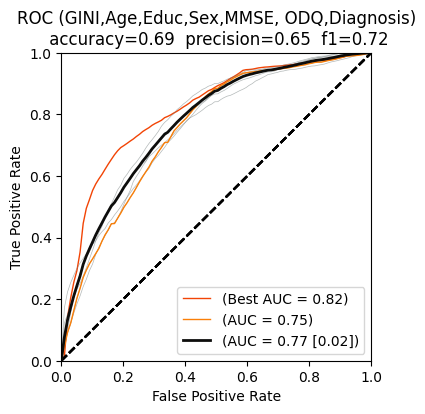

In [ ]:
plt.figure(figsize=(4,4))
graph_roc(gini_age_results, top_10_keys_GINI_age, title = 'GINI,Age,Educ,Sex,MMSE, ODQ,Diagnosis')


In [ ]:
df_metrics_dir_2 =  df_metrics_dir_.copy()
df_metrics_dir_2.replace({'negative': -1, 'positive': 1}, inplace=True)
df_metrics_dir_2.fillna(0, inplace=True)
df_metrics_dir_2

In [ ]:
plt.figure(figsize=(20,10))



graph_feat_impor_t2_S(df_metrics_dir_2,df_metrics_pval_,df_metrics_slopes_,df_metrics_correlation_,gini_age_results, top_10_keys_GINI_age, gini_plus_var=True, title = '+ Age,Educ,GINI,Sex,MMSE,Diagnosis,ODQ')


In [ ]:
import matplotlib.pyplot as plt
!pip install matplotlib pandas xlsxwriter tabulate
import numpy as np
import pandas as pd
from tabulate import tabulate
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
!pip install pandas
import pandas as pd
!pip install xlsxwriter
import os
import matplotlib.colors as mcolors
#gini_plus_var=True,



def graph_feat_impor_t2_S(df_metrics_dir, df_metrics_pval, df_metrics_slopes_,df_metrics_correlation_, gini_results_metric, top_10_keys_metric, gini_plus_var=True,  title=''):
    cantidad = 7
    count = 1
    page_number = 1
    ordered_features = ['GINI', 'Age', 'ODQ', 'Sex', 'Diagnosis', 'Educ', 'MMSE']



    variables_expectations = {
      'GINI': 'negative',
      'Age': 'negative',
      'Sex': 'negative',
      'Diagnosis': 'negative',
      'Educ': 'positive',
      'MMSE': 'positive',
      'ODQ': 'positive'
    }


    colors = ['blue', 'gray', 'green']


    nodes = [0.0, 0.5, 1.0]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", list(zip(nodes, colors)))


    summary_df = pd.DataFrame(columns=['Model', 'Correct (%)', 'Incorrect (%)'])
    correct_pred_df = pd.DataFrame(columns=['Model', 'Predictor'])
    incorrect_pred_df = pd.DataFrame(columns=['Model', 'Predictor'])

    normalized_correlations = {}

    global_min = -abs(df_metrics_correlation_.max().max())
    global_max = abs(df_metrics_correlation_.max().max())

    all_feature_outcomes = []


    writer = pd.ExcelWriter(f'{base_path}mugre.xlsx', engine='xlsxwriter')
    writer2 = pd.ExcelWriter(f'{base_path}mugre_.xlsx', engine='xlsxwriter')


    for i, key in enumerate(top_10_keys_metric):
        auc = np.mean(gini_results_metric[key][1]['test']['auc'])
        acc = np.mean(gini_results_metric[key][1]['test']['accuracy_score'])
        prec = np.mean(gini_results_metric[key][1]['test']['precision_score'])
        f1 = np.mean(gini_results_metric[key][1]['test']['f1_score'])
        rec = np.mean(gini_results_metric[key][1]['test']['recall_score'])

        auc_std = np.std(gini_results_metric[key][1]['test']['auc'])
        acc_std = np.std(gini_results_metric[key][1]['test']['accuracy_score'])
        prec_std = np.std(gini_results_metric[key][1]['test']['precision_score'])
        f1_std = np.std(gini_results_metric[key][1]['test']['f1_score'])
        rec_std = np.std(gini_results_metric[key][1]['test']['recall_score'])

        conf_matrix = gini_results_metric[key][1]['test']['confusion_matrix']
        conf_matrix_mean = np.mean(conf_matrix, axis=0)
        conf_matrix_std = np.std(conf_matrix, axis=0)

        fscore = {k: [] for k in ['GINI', 'Age', 'Educ', 'Sex', 'MMSE', 'ODQ', 'Diagnosis']}
        model_idx = 0  # Para numerar los modelos
        model_summary = []

        for model in gini_results_metric[key][1]['test']['model']:


                model_fscore = model.get_fscore()

                model_features = list(model_fscore.keys())

                # Control de estado
                if gini_plus_var and len(model_features) < cantidad:
                    status = "Descartado"
                    print(f"-> Modelo #{model_idx} descartado (menos de {cantidad} features)")
                    model_idx += 1
                    # Guardar resumen del modelo descartado
                    model_summary.append({
                        "Key": key,
                        "Modelo": model_idx - 1,
                        "Estado": status,
                        "Cantidad_features": len(model_features),
                        "Features": ", ".join(model_features)
                    })
                    continue

                else:
                    status = "Incluido"
                    print(f"-> Modelo #{model_idx} incluido ✅")

                    for j in model_fscore.keys():
                        if gini_plus_var and len(model_fscore.keys()) < cantidad:
                            continue
                        if j in fscore:
                            fscore[j].append(model_fscore[j])
                        else:
                            fscore[j] = [model_fscore[j]]

                print(len(fscore))

                # Guardar resumen del modelo incluido
                model_summary.append({
                    "Key": key,
                    "Modelo": model_idx,
                    "Estado": status,
                    "Cantidad_features": len(model_features),
                    "Features": ", ".join(model_features)
                })
                model_idx += 1


        df_models = pd.DataFrame(model_summary)

        df_models.to_excel(writer, sheet_name=str(key), index=False)


        index = ['Age', 'Educ', 'GINI', 'Sex', 'MMSE', 'ODQ', 'Diagnosis']

        feature_outcome = {feature: {'Correct': 0, 'Incorrect': 0} for feature in index}

        df = pd.DataFrame.from_dict(fscore, orient='index')
        df = df.transpose()

        if df.empty:
          continue

        for column in index:
            if column not in df.columns:
                df[column] = 0

        df[ordered_features] = df[ordered_features].fillna(0)

        plt.subplot(2, 4, count)
        mean_values = df.mean()
        std_values = df.std()

        if df_metrics_dir is not None:
            mean_values_filtered = mean_values.copy()
            for feature in mean_values.index:
                if feature in df_metrics_dir.index and key in df_metrics_dir.columns:
                    pval = df_metrics_pval.loc[feature, key]
                    mean_values_filtered[feature] = mean_values.get(feature, 1) * np.sign(df_metrics_dir.loc[feature, key])

            mean_values_filtered = mean_values_filtered.fillna(0)
            std_values = std_values.loc[mean_values_filtered.index]


            mean_values_filtered = mean_values_filtered.loc[ordered_features]
            std_values = std_values.loc[ordered_features]


            correlation_series = df_metrics_correlation_.loc[ordered_features, key]
            slope_series = df_metrics_slopes_.loc[ordered_features, key]

            correlation_values = []
            df_metrics_slopes_values = []

            for feature in ordered_features:
                correlation_str = correlation_series.loc[feature]
                slope_str = slope_series.loc[feature]

                if isinstance(correlation_str, (int, float, np.floating)):
                    correlation_str = str(correlation_str).replace("–", "-")

                if isinstance(slope_str, bytes):
                    slope_str = slope_str.decode('utf-8')

                try:
                    if isinstance(correlation_str, str):


                      correlation_str = correlation_str.replace("–", "-")
                      correlation_value = extraer_valor_numerico_(correlation_str)

                    correlation_value = extraer_valor_numerico_(correlation_str)
                    slope_value = extraer_valor_numerico(slope_str)
                except ValueError:
                    correlation_value = None
                    slope_value = None


                correlation_values.append(correlation_value)
                df_metrics_slopes_values.append(slope_value)

                if pd.notna(correlation_value):
                    correlation_value = round(correlation_value, 6)

                    if correlation_value > 1:
                        correlation_value = 1


                        correlation_value = 1
                    elif correlation_value < -1:
                        correlation_value = -1

                        correlation_value = -1
                        correlation_values.append(correlation_value)
                        df_metrics_slopes_values.append(slope_value if pd.notna(slope_value) else None)
                else:
                    df_metrics_slopes_values.append(None)
                    correlation_values.append(None)


            valid_correlations = [val for val in correlation_values if val is not None]

            color_list = ['green' if val > 0 else 'blue' if val < 0 else 'red' for val in mean_values_filtered]

            colors = [(0.5, 0, 0), (1, 1, 1), (1, 0.2, 0.2)]  # Rojo oscuro, blanco, rojo oscuro
            nodes = [0.0, 0.5, 1.0]
            red_cmap = mcolors.LinearSegmentedColormap.from_list("red_cmap", list(zip(nodes, colors)))

            # Crear un subplot y asignar a ax
            ax = plt.subplot(2, 4, count)

            correlation_min = -1
            correlation_max = 1
            norm = plt.Normalize(correlation_min, correlation_max)
            sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
            sm.set_array([])

            red_norm = plt.Normalize(-1, 1)  # Ajusta este rango según lo que necesites
            red_sm = plt.cm.ScalarMappable(cmap=red_cmap, norm=red_norm)
            red_sm.set_array([])

            for feature, correlation_value in zip(mean_values_filtered.index, correlation_values):
                    print(f"Métrica: {key}, Característica: {feature}, Correlación: {correlation_value}")


            negative_blue = set()
            positive_green = set()

            # Definir expectativas de las variables
            variables_expectations = {
                'GINI': 'negative',
                'Age': 'negative',
                'Sex': 'negative',
                'Diagnosis': 'negative',
                'Educ': 'positive',
                'MMSE': 'positive',
                'ODQ': 'positive'
            }

            # Definir expectativas específicas para los offsets
            metrics_expectations = {
                'Offset_HPC_left': 'positive',
                'Offset_HPC_right': 'positive',
                'Offset_CING_left': 'positive',
                'Offset_CING_right': 'positive',
                'Offset_TEMP_left': 'positive',
                'Offset_TEMP_right': 'positive',
                'Offset_PARIET_left': 'positive',
                'Offset_PARIET_right': 'positive',
                'Offset_OCC_left': 'positive',
                'Offset_OCC_right': 'positive',
                'Age': 'positive'  # Asegúrate de incluirlo si es necesario aquí
            }


            for feature, correlation_value,slope in zip(mean_values_filtered.index, correlation_values,df_metrics_slopes_values):
                        print(f"Métrica: {key}, Característica: {feature}, Correlación: {correlation_value}, Pendiente:{slope}" )


            incorrect_counts = {feature: 0 for feature in mean_values_filtered.index}

            correlation_per_feature = {feature: [] for feature in mean_values_filtered.index}

            for feature, value, error in zip(mean_values_filtered.index, mean_values_filtered.values, std_values.values):
                idx = mean_values_filtered.index.get_loc(feature)
                correlation_value = correlation_values[idx]
                df_metrics_slopes_value = df_metrics_slopes_values[idx]

                print(f"Procesando: {feature}, Valor: {value}, Error: {error}, Correlación: {correlation_value}, Slopewwww: {df_metrics_slopes_value}")


                if key in metrics_expectations and feature=='Age':
                    expectation = metrics_expectations[feature]
                else:
                    expectation = variables_expectations.get(feature, None)  # Usar la expectativa general o 'negative' por defecto



                if expectation == 'positive':
                    positive_green.add(feature)
                else:
                    negative_blue.add(feature)

                correctos = []
                incorrectos = []
                aux = 0
                aux2 = 0



                epsilon = 1e-6
                try:
                  df_metrics_slopes_value = float(df_metrics_slopes_value)
                except ValueError:
                  df_metrics_slopes_value = np.nan  # o manejar como prefieras
                  # Verificar si la dirección del efecto es correcta según la pendiente
                if correlation_value is not None and not np.isnan(df_metrics_slopes_value):
                    if (expectation == 'positive' and df_metrics_slopes_value > 0) or \
                       (expectation == 'negative' and df_metrics_slopes_value < 0):
                         correlation_per_feature[feature].append(correlation_value)
                         feature_outcome[feature]['Correct'] += 1
                    else:
                         feature_outcome[feature]['Incorrect'] += 1



                feature_outcome_df = pd.DataFrame.from_dict(feature_outcome, orient='index').reset_index()
                feature_outcome_df.rename(columns={'index': 'Feature'}, inplace=True)


                feature_outcome_df['Model'] = key

                all_feature_outcomes.append(feature_outcome_df)




            all_avg_corrs = [np.mean(correlation_per_feature[f]) for f in correlation_per_feature if correlation_per_feature[f]]

            abs_max = max(abs(np.nanmin(all_avg_corrs)), abs(np.nanmax(all_avg_corrs)))

            correlation_min = -abs_max
            correlation_max = abs_max


            norm = plt.Normalize(global_min, global_max)
            sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
            sm.set_array([])


            for feature in mean_values_filtered.index:
                avg_correct_corr = np.mean(correlation_per_feature[feature]) if correlation_per_feature[feature] else np.nan

                if not np.isnan(avg_correct_corr):
                    color = sm.to_rgba(avg_correct_corr)
                else:
                    color = 'white'

                plt.barh(feature, abs(mean_values_filtered[feature]), xerr=std_values[feature], capsize=4, color=color, align='center', edgecolor='black')
            plt.colorbar(sm, ax=plt.gca(), label='Correlation Coefficient')


        ax = plt.gca()
        ax.set_xlim(left=0)#


        writer.close()

        plt.axvline(x=0, color='black', linestyle='--')
        plt.ylabel('Features')
        plt.xlabel('Estimate')
        plt.title(f'{key}\n auc={auc:.2f} accuracy={acc:.2f} precision={prec:.2f} \n f1={f1:.2f} recall={rec:.2f}')

        plt.subplot(2, 4, count + 4)
        plt.imshow(conf_matrix_mean, interpolation='nearest', cmap=plt.cm.Greys)
        plt.title(f'{key}')
        plt.colorbar()

        tick_marks = np.arange(len(['Low', 'High']))
        plt.xticks(tick_marks, ['Low', 'High'])
        plt.yticks(tick_marks, ['Low', 'High'])
        plt.ylabel('True')
        plt.xlabel('Predict')

        for row in range(conf_matrix_mean.shape[0]):
            for col in range(conf_matrix_mean.shape[1]):
                plt.text(col, row, f"{conf_matrix_mean[row, col]:.2f}\n({conf_matrix_std[row, col]:.2f})",
                         ha="center", va="center", color="white" if conf_matrix_mean[row, col] > 30 else "black")
        visible_features = [
            feature for feature in mean_values_filtered.index
            if not np.isnan(mean_values_filtered[feature])
        ]

        correct_visible_features = [
            feature for feature in visible_features
            if (feature in positive_green and mean_values_filtered[feature] > 0) or
               (feature in negative_blue and mean_values_filtered[feature] < 0)
        ]

        incorrect_visible_features = [
            feature for feature in visible_features
            if (feature in positive_green and mean_values_filtered[feature] < 0) or
               (feature in negative_blue and mean_values_filtered[feature] > 0)
        ]


        correct_visible_count = len(correct_visible_features)
        incorrect_visible_count = len(incorrect_visible_features)

        total_visible_count = correct_visible_count + incorrect_visible_count
        correct_visible_pct = (correct_visible_count / total_visible_count * 100) if total_visible_count > 0 else 0
        incorrect_visible_pct = (incorrect_visible_count / total_visible_count * 100) if total_visible_count > 0 else 0

        summary_df = pd.concat([summary_df,
                               pd.DataFrame({
                                   'Model': [key],
                                   'Correct (Blue)': [len([feature for feature in correct_visible_features if feature in negative_blue])],
                                   'Incorrect (Blue)': [len([feature for feature in incorrect_visible_features if feature in negative_blue])],
                                   'Correct (Orange)': [len([feature for feature in correct_visible_features if feature in positive_green])],
                                   'Incorrect (Orange)': [len([feature for feature in incorrect_visible_features if feature in positive_green])],
                                   'Correct (%)': [correct_visible_pct],
                                   'Incorrect (%)': [incorrect_visible_pct]
                               })
                              ],ignore_index=True)

        for feature in correct_visible_features:
            correct_pred_df = pd.concat([correct_pred_df, pd.DataFrame([{'Model': key, 'Predictor': feature}])], ignore_index=True)
        for feature in incorrect_visible_features:
            incorrect_pred_df = pd.concat([incorrect_pred_df, pd.DataFrame([{'Model': key, 'Predictor': feature}])], ignore_index=True)



        count += 1


        metrics = {
            'AUC': [auc, auc_std],
            'Accuracy': [acc, acc_std],
            'Precision': [prec, prec_std],
            'F1 Score': [f1, f1_std],
            'Recall': [rec, rec_std]
        }
        df_metrics = pd.DataFrame(metrics, index=['Mean', 'STD'])

        mean_fscore = df.mean()
        std_fscore = df.std()
        fscores_ = pd.DataFrame({'mean': mean_fscore, 'SD': std_fscore})

        df_conf_m = pd.DataFrame(conf_matrix_mean, index=['Low', 'High'], columns=['Low', 'High'])
        df_conf_s = pd.DataFrame(conf_matrix_std, index=['Low', 'High'], columns=['Low', 'High'])

        with pd.ExcelWriter(f'{base_path}/conect_GINI_{title}_rank_{count - 1}_{key}.xlsx', engine='xlsxwriter') as writer:
            df_metrics.to_excel(writer, sheet_name='metrics')
            fscores_.to_excel(writer, sheet_name='fscores')
            df_conf_m.to_excel(writer, sheet_name='conf_mat_mean')
            df_conf_s.to_excel(writer, sheet_name='conf_mat_std')

        if count % 4 == 0  or (i == len(top_10_keys_metric) - 1):
          plt.tight_layout()
          plt.savefig(f'{base_path}figure_{title}_page_{i//4 + 1}.pdf', format='pdf')
          plt.savefig(f'{base_path}figure_{title}_page_{i//4 + 1}.svg', format='svg')
          plt.show()
          plt.figure(figsize=(20, 10))
          count = 1


    plt.tight_layout()
    plt.savefig(f'{base_path}figure_{title}_.svg', format='svg', facecolor='white')
    plt.savefig(f'{base_path}figure_{title}_.pdf', format='pdf', facecolor='white')
    plt.show()
    plt.close()


    predictor_summary = {predictor: {'Correct': 0, 'Incorrect': 0} for predictor in variables_expectations.keys()}

    for feature in mean_values_filtered.index:
        correlation_value = correlation_values[mean_values_filtered.index.get_loc(feature)]
        expectation = variables_expectations.get(feature, None)

        if expectation:
            if (expectation == 'positive' and correlation_value >= 0) or (expectation == 'negative' and correlation_value <= 0):
                predictor_summary[feature]['Correct'] += 1
            else:
                predictor_summary[feature]['Incorrect'] += 1

    predictor_summary_df = pd.DataFrame.from_dict(predictor_summary, orient='index').reset_index()
    predictor_summary_df.rename(columns={'index': 'Predictor'}, inplace=True)

    with pd.ExcelWriter(f'{base_path}summary_{title}.xlsx', engine='xlsxwriter') as writer:
        summary_df.to_excel(writer, sheet_name='summary', index=False)
        correct_pred_df.to_excel(writer, sheet_name='correct_predictors', index=False)
        incorrect_pred_df.to_excel(writer, sheet_name='incorrect_predictors', index=False)
        predictor_summary_df.to_excel(writer, sheet_name='predictor_summary', index=False)


    print("\nPredictor Summary Table:")
    print(tabulate(predictor_summary_df, headers='keys', tablefmt='grid', showindex=False))



In [ ]:
def extraer_valor_numerico_(s):
    if isinstance(s, bytes):
        s = s.decode("utf-8")

    s = str(s).replace("–", "-").strip()

    try:
        valor = float(s)

        return valor
    except ValueError:

        return None

In [ ]:
import re

def extraer_valor_numerico(s):

    if isinstance(s, bytes):
        s = s.decode('utf-8')

    s = str(s).replace("–", "-")



    match = re.search(r"([-+]?\d*\.\d+|\d+)", s)

    if match:
        return float(match.group(0))
    else:
        return None


In [ ]:

!pip install xlsxwriter


import pandas as pd
import numpy as np
import pickle
import xlsxwriter
import matplotlib.pyplot as plt


with open(f'{base_path}df_metrics_slopes_todo_.pkl', 'rb') as f:
    df_metrics_slopes_todo_ = pickle.load(f)

expanded_records = []
for predictor_index, row in df_metrics_slopes_todo_.iterrows():
    predictor_name = predictor_index
    for outcome_column, slopes_data in row.items():
        slopes_list = slopes_data if isinstance(slopes_data, list) else [slopes_data]
        for slope_value in slopes_list:
            expanded_records.append({
                'Predictor': predictor_name,
                'Outcome': outcome_column,
                'Slope': slope_value
            })

df_expandido = pd.DataFrame(expanded_records)
df_expandido['Slope'] = pd.to_numeric(df_expandido['Slope'], errors='coerce')

variables_expectations = {
    'GINI': 'negative', 'Age': 'negative', 'Sex': 'negative', 'Diagnosis': 'negative',
    'Educ': 'positive', 'MMSE': 'positive', 'ODQ': 'positive'
}

metrics_expectations = {
    'Offset_HPC_left': 'positive', 'Offset_HPC_right': 'positive',
    'Offset_CING_left': 'positive', 'Offset_CING_right': 'positive',
    'Offset_TEMP_left': 'positive', 'Offset_TEMP_right': 'positive',
    'Offset_PARIET_left': 'positive', 'Offset_PARIET_right': 'positive',
    'Offset_OCC_left': 'positive', 'Offset_OCC_right': 'positive',
    'Age': 'positive'
}


expected_directions = {**variables_expectations, **metrics_expectations}

resultados_por_feature = {}
for outcome in df_expandido['Outcome'].unique():
    df_outcome = df_expandido[df_expandido['Outcome'] == outcome].copy()
    outcome_predictor_summary = {predictor: {'Correct': 0, 'Incorrect': 0, 'Total_models': 0} for predictor in df_outcome['Predictor'].unique()}

    for _, row in df_outcome.iterrows():
        predictor, slope_val = row['Predictor'], row['Slope']
        expected = expected_directions.get(predictor, None)


        if predictor == 'Age' and outcome in metrics_expectations:
            expected = 'positive'
        elif predictor == 'Age':
            expected = 'negative'


        print(f'Outcome: {outcome}, Predictor: {predictor}, Expected Direction: {expected}')



        outcome_predictor_summary[predictor]['Total_models'] += 1
        if expected and pd.notna(slope_val):
            if (expected == 'positive' and slope_val > 0) or (expected == 'negative' and slope_val < 0):
                outcome_predictor_summary[predictor]['Correct'] += 1
            else:
                outcome_predictor_summary[predictor]['Incorrect'] += 1

    outcome_results_list = [
        {"Predictor": predictor, "Modelos_correctos": counts['Correct'],
         "Total_modelos": counts['Total_models'], "Modelos_incorrectos": counts['Incorrect'],
         "Porcentaje_correctos": (counts['Correct'] / counts['Total_models']) * 100 if counts['Total_models'] > 0 else 0,
         "Porcentaje_incorrectos": (counts['Incorrect'] / counts['Total_models']) * 100 if counts['Total_models'] > 0 else 0}
        for predictor, counts in outcome_predictor_summary.items()
    ]

    resultados_por_feature[outcome] = pd.DataFrame(outcome_results_list)


with pd.ExcelWriter(f'{base_path}porcentajes_correctos_por_featureXX_.xlsx', engine="xlsxwriter") as writer:
    for outcome, df_resultados in resultados_por_feature.items():
        df_resultados.to_excel(writer, sheet_name=outcome, index=False)

        plot_features = df_resultados["Predictor"].tolist()
        accuracy_percentages = df_resultados["Porcentaje_correctos"].values
        incorrect_percentages = df_resultados["Porcentaje_incorrectos"].values

        if not plot_features:
            print(f"Skipping polar plot for outcome {outcome} as there are no contributing predictors.")
            continue

        accuracy_percentages = np.append(accuracy_percentages, accuracy_percentages[0])
        incorrect_percentages = np.append(incorrect_percentages, incorrect_percentages[0])

        num_vars = len(plot_features)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        ax.fill(angles, accuracy_percentages, color='blue', alpha=0.3)
        ax.plot(angles, accuracy_percentages, color='blue', linewidth=2, linestyle='solid')

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(plot_features, fontsize=10)
        ax.set_ylim(0, 100)
        ax.set_title(f'Direction Agreement for Outcome: {outcome}', va='bottom')
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

        plt.savefig(f'{base_path}/{outcome}_polarXX_.svg', format="svg", dpi=300)
        plt.savefig(f'{base_path}/{outcome}_polarXX_.pdf', format="pdf", dpi=300)
        plt.close(fig)

